# **Ievads attēlu apstrādē**

## **Praktiskais darbs Nr. 4**

---

**Students:** Edgars Polis

**Studenta apliecības Nr.:** 241RDB296

**Saite uz programmēšanas kodu:** https://github.com/Edgars-P/RTU_IAA_MD/blob/main/LD4/IAA_LD4.ipynb

---

**Variants 6**

- Canny robežu detektors
- Roberts operators

<table>
<tr>
<td>
<img src="objekts.jpg" width="300"/>
</td> 
<td>
<img src="brivs.jpg" width="300"/>
</td>
</tr>
</table>


## **Programmas kods ar izvadi**


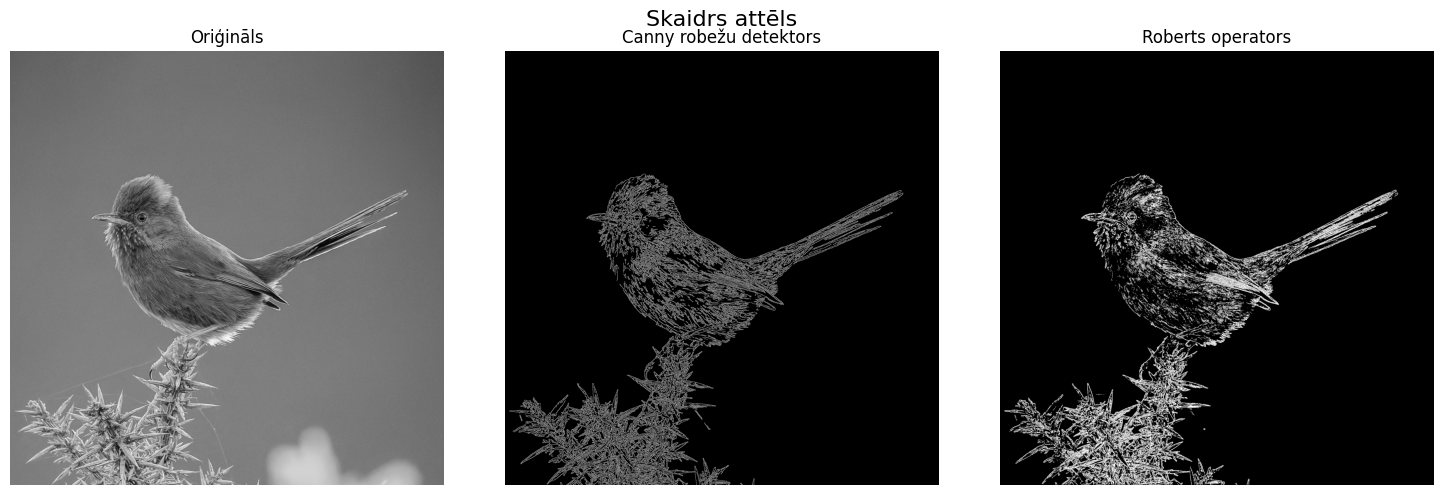

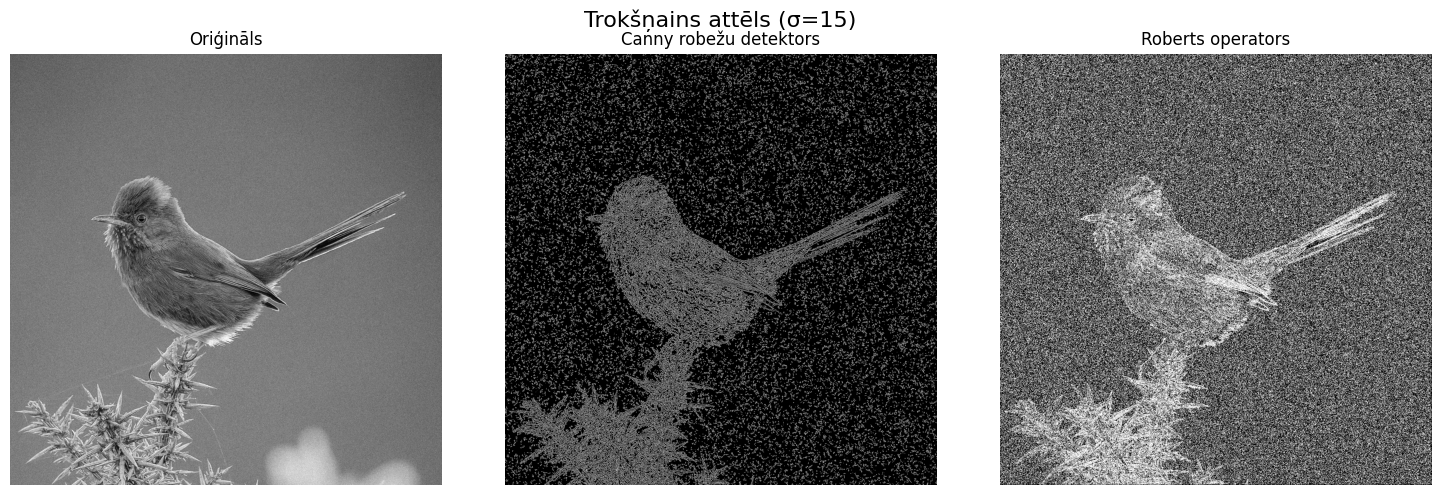

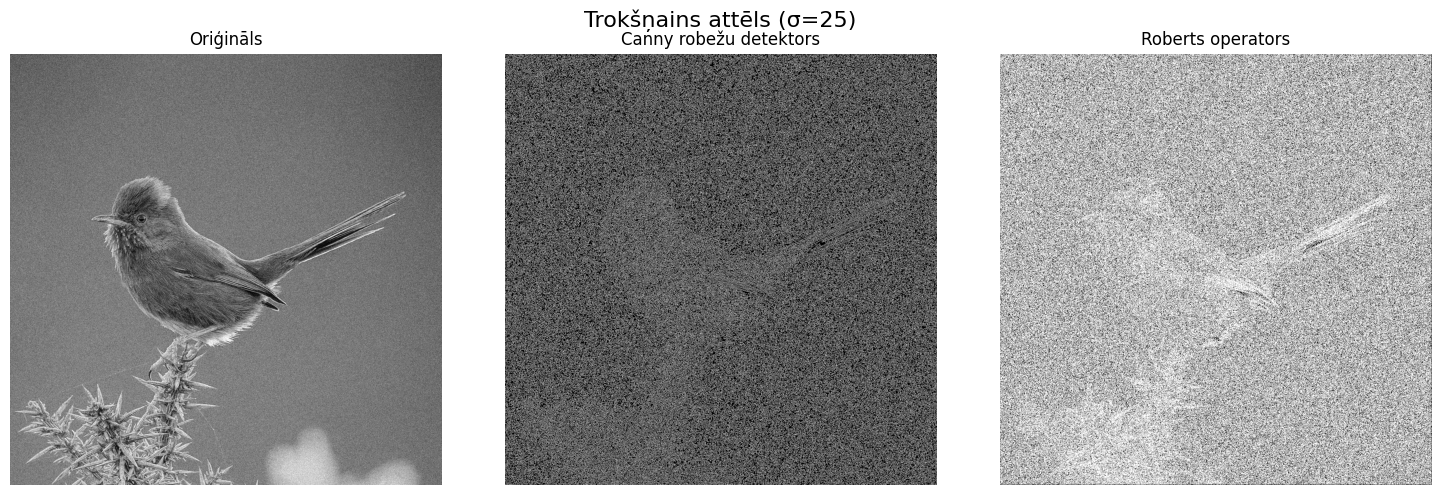

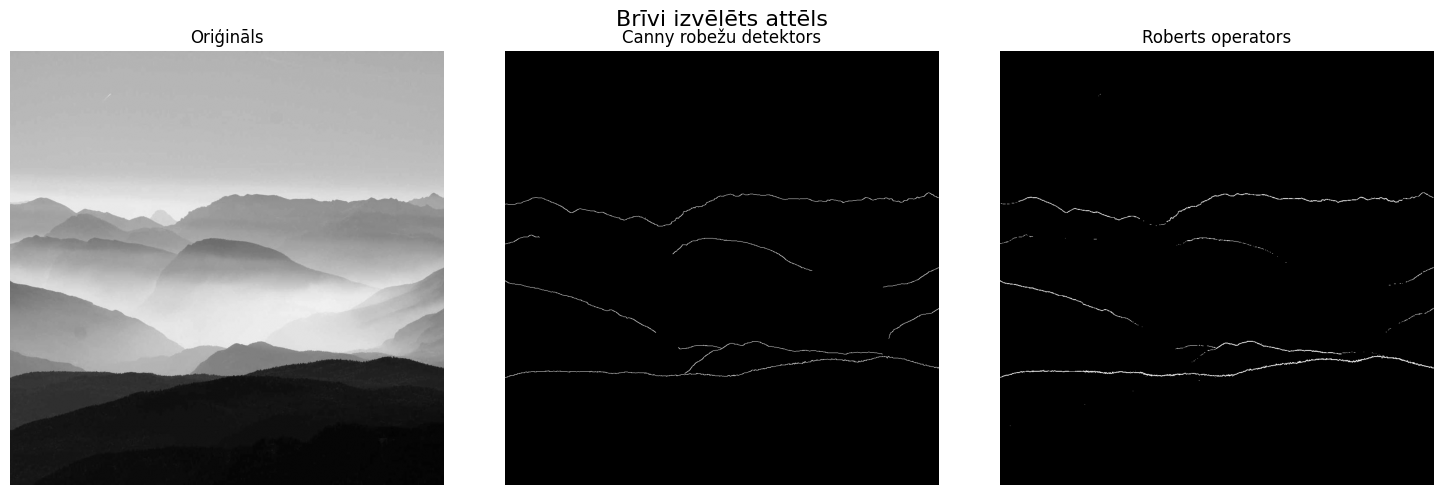

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_gaussian_noise(image, sigma=15):
    row, col = image.shape
    gauss = np.random.normal(0, sigma, (row, col))
    noisy = image.astype(np.float32) + gauss
    return np.clip(noisy, 0, 255).astype(np.uint8)

def manual_roberts(image, threshold=30):
    img = image.astype(np.float64)
    Gx = np.zeros_like(img)
    Gy = np.zeros_like(img)
    
    Gx[:-1, :-1] = img[:-1, :-1] - img[1:, 1:]
    Gy[:-1, :-1] = img[:-1, 1:] - img[1:, :-1]
    
    G = np.sqrt(Gx**2 + Gy**2)
    result = np.zeros_like(img)
    result[G > threshold] = 255
    return result.astype(np.uint8)

def process_and_display(image, title):
    canny_edges = cv2.Canny(image, 100, 200)
    roberts_edges = manual_roberts(image, 30)
    
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    
    axs[0].imshow(image, cmap='gray')
    axs[0].set_title("Oriģināls")
    axs[0].axis("off")
    
    axs[1].imshow(canny_edges, cmap='gray')
    axs[1].set_title("Canny robežu detektors")
    axs[1].axis("off")
    
    axs[2].imshow(roberts_edges, cmap='gray')
    axs[2].set_title("Roberts operators")
    axs[2].axis("off")
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

img_clear = cv2.imread("./objekts.jpg", cv2.IMREAD_GRAYSCALE)
img_free = cv2.imread("./brivs.jpg", cv2.IMREAD_GRAYSCALE)

img_noisy = add_gaussian_noise(img_clear)
img_noisy_25 = add_gaussian_noise(img_clear, sigma=25)

process_and_display(img_clear, "Skaidrs attēls")
process_and_display(img_noisy, "Trokšņains attēls (σ=15)")
process_and_display(img_noisy_25, "Trokšņains attēls (σ=25)")
process_and_display(img_free, "Brīvi izvēlēts attēls")

**Kādas atšķirības ir redzamas starp dažādiem malu noteikšanas algoritmiem?**  
Canny metode izveido daudz izteiktākas, vienmērīga biezuma un nepārtrauktas malas, kamēr Robertsa operatoram tās ir daudz haotiskākas un īsākas. Tas ir īpaši labi redzams kalna gadījumā.

**Kura metode labāk identificē objektu malas un kādu ietekmi uz rezultātiem atstāj troksnis?**  
Labāk malas identificē Canny detektors. Tās ir nepārtrauktas, un kalnos spēj atrast daudz lielāku daļu no kontūras. Canny detektors arī daudz labāk tiek galā ar troksni, kaut gan, paceļot trokšņa sigma uz 25, abu metožu rezultāti kļūst salīdzinoši līdzīgi nelasāmi, neskatoties uz to, ka pats attēls ar neapbruņotu aci joprojām ir skaidrs.

**Kādas ir katras metodes priekšrocības un trūkumi?**  
Canny metode daudz labāk tiek galā ar troksni un atrod vairāk robežu. Gala robežas arī ir skaidras un nepārtrauktas. Taču tā ir daudz sarežģītāka un matemātiski intensīvāka.  
Robertsa operators ir ļoti ātrs un vienkāršs, jo sastāv tikai no 2x2 matricas. Bet tas ir daudz jutīgāks pret troksni, un atrastās malas ir sliktāk definētas.

**Kā algoritmi darbojas dažāda tipa attēlos?**  
Skaidros attēlos ar labu kontrastu abas metodes var sekmīgi atrast malas ar pieņemamu rezultātu.  
Pievienojot troksni, Canny metode var daudz labāk noturēt malas, bet Robertsa operators tās ļoti ātri pazaudē.  
Attēlos ar sliktāku kontrastu un neskaidrākām robežām (kalnu ainava) Canny operators var saskatīt vairāk robežu pat tajās daļās, kur kontrasts ir pārāk mazs Robertsa operatoram.
